In [2]:
# =========================================
# IMPORT LIBRARY
# =========================================

import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# =========================================
# 4.1 DATA CLEANING & PREPARATION
# =========================================

# load dataset
df = pd.read_excel("edited data TA.xlsx")

# seleksi kolom yang digunakan
df = df[['Tanggal Job', 'Jumlah Cylinder']]

# konversi kolom tanggal ke datetime
df['Tanggal Job'] = pd.to_datetime(df['Tanggal Job'])

# cek hasil awal
print(df.head())

  Tanggal Job  Jumlah Cylinder
0  2025-01-01                9
1  2025-01-01                9
2  2025-01-01                4
3  2025-01-02                9
4  2025-01-02                8


In [4]:
# =========================================
# CEK MISSING VALUE
# =========================================

print("Missing Value:\n", df[['Tanggal Job', 'Jumlah Cylinder']].isnull().sum())

Missing Value:
 Tanggal Job        0
Jumlah Cylinder    0
dtype: int64


In [5]:
# =========================================
# AGREGASI DATA HARIAN DAN MINGGUAN
# =========================================

# jadikan Tanggal Job sebagai index waktu
df = df.set_index('Tanggal Job')

# agregasi transaksi menjadi data harian
df_daily = df['Jumlah Cylinder'].resample('D').sum()

# agregasi data harian menjadi data mingguan
df_weekly = df_daily.resample('W').sum()

# isi missing value jika ada
df_weekly = df_weekly.ffill()

# cek hasil akhir
print("\nJumlah data weekly:", len(df_weekly))
print(df_weekly.head())


Jumlah data weekly: 53
Tanggal Job
2025-01-05    106
2025-01-12    147
2025-01-19    181
2025-01-26    173
2025-02-02    169
Freq: W-SUN, Name: Jumlah Cylinder, dtype: int64


In [6]:
# =========================================
# TRAIN TEST SPLIT
# =========================================

train_size = int(len(df_weekly) * 0.8)

train = df_weekly.iloc[:train_size]
test = df_weekly.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 42
Test size: 11


In [7]:
# =========================================
# FUNGSI EVALUASI
# =========================================

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-5))) * 100
    return mae, rmse, mape

In [8]:
# =========================================
# BASELINE MODEL
# =========================================

# -------------------------
# NAIVE MODEL
# -------------------------
history = train.tolist()
naive_pred = []

for t in range(len(test)):
    yhat = history[-1]
    naive_pred.append(yhat)
    history.append(test.iloc[t])

# -------------------------
# MOVING AVERAGE
# -------------------------
window = 3

history = train.tolist()
ma_pred = []

for t in range(len(test)):
    yhat = np.mean(history[-window:])
    ma_pred.append(yhat)
    history.append(test.iloc[t])

In [9]:
# =========================================
# PEMILIHAN PARAMETER ARIMA TERBAIK
# =========================================

p_values = range(0, 4)
d_values = range(0, 3)
q_values = range(0, 4)

arima_results = []

for order in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit()

        pred = model_fit.forecast(steps=len(test))

        mae, rmse, mape = evaluate(test, pred)

        arima_results.append({
            "Order": order,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape,
            "AIC": model_fit.aic
        })

    except Exception:
        continue

arima_results = pd.DataFrame(arima_results)

# urutkan berdasarkan MAPE terkecil
arima_results = arima_results.sort_values(by="MAPE").reset_index(drop=True)

print("Top 10 Kandidat ARIMA Terbaik Berdasarkan MAPE:")
print(arima_results.head(10))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWar

Top 10 Kandidat ARIMA Terbaik Berdasarkan MAPE:
       Order        MAE       RMSE       MAPE         AIC
0  (3, 0, 3)  28.827278  46.631995  15.543844  387.038225
1  (2, 1, 0)  28.152888  48.663720  15.982196  376.166923
2  (3, 0, 0)  31.288207  47.898519  16.304451  390.772865
3  (2, 1, 3)  27.887592  49.811371  16.419287  372.454942
4  (2, 1, 2)  29.543213  49.062840  16.525162  377.670027
5  (3, 1, 0)  29.360645  49.085236  16.529754  377.171675
6  (3, 1, 2)  29.643192  49.071071  16.547236  379.639027
7  (3, 1, 1)  29.727377  49.152051  16.605325  377.697768
8  (2, 1, 1)  29.864128  49.210183  16.657565  375.712642
9  (0, 1, 1)  31.249908  49.311362  16.777153  383.025124


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [10]:
# =========================================
# TABEL TOP 5 KANDIDAT ARIMA TERBAIK
# =========================================

top5_arima = arima_results.head(5).copy()

# ubah nama kolom agar lebih rapi
top5_arima = top5_arima.rename(columns={
    "Order": "Model ARIMA"
})

# ubah format model agar tampil sebagai ARIMA(p,d,q)
top5_arima["Model ARIMA"] = top5_arima["Model ARIMA"].apply(
    lambda x: f"ARIMA{x}"
)

# pembulatan angka
top5_arima["MAE"] = top5_arima["MAE"].round(2)
top5_arima["RMSE"] = top5_arima["RMSE"].round(2)
top5_arima["MAPE"] = top5_arima["MAPE"].round(2)
top5_arima["AIC"] = top5_arima["AIC"].round(2)

# tambahkan kolom peringkat
top5_arima.insert(0, "Peringkat", range(1, len(top5_arima) + 1))

print("Tabel Top 5 Kandidat ARIMA Terbaik:")
print(top5_arima)

Tabel Top 5 Kandidat ARIMA Terbaik:
   Peringkat     Model ARIMA    MAE   RMSE   MAPE     AIC
0          1  ARIMA(3, 0, 3)  28.83  46.63  15.54  387.04
1          2  ARIMA(2, 1, 0)  28.15  48.66  15.98  376.17
2          3  ARIMA(3, 0, 0)  31.29  47.90  16.30  390.77
3          4  ARIMA(2, 1, 3)  27.89  49.81  16.42  372.45
4          5  ARIMA(2, 1, 2)  29.54  49.06  16.53  377.67


In [11]:
top5_arima

,Peringkat,Model ARIMA,MAE,RMSE,MAPE,AIC
0,1,"ARIMA(3, 0, 3)",28.83,46.63,15.54,387.04
1,2,"ARIMA(2, 1, 0)",28.15,48.66,15.98,376.17
2,3,"ARIMA(3, 0, 0)",31.29,47.90,16.30,390.77
3,4,"ARIMA(2, 1, 3)",27.89,49.81,16.42,372.45
4,5,"ARIMA(2, 1, 2)",29.54,49.06,16.53,377.67


In [12]:
# =========================================
# AMBIL PARAMETER ARIMA TERBAIK
# =========================================

best_order = arima_results.iloc[0]["Order"]

print("Best ARIMA Order:", best_order)

Best ARIMA Order: (3, 0, 3)


In [13]:
# =========================================
# MODEL ARIMA FINAL
# =========================================

model = ARIMA(train, order=best_order)
model_fit = model.fit()

arima_pred = model_fit.forecast(steps=len(test))

print("ARIMA Order yang digunakan:", best_order)

ARIMA Order yang digunakan: (3, 0, 3)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [14]:
# =========================================
# EVALUASI MODEL
# =========================================

naive_mae, naive_rmse, naive_mape = evaluate(test, naive_pred)
ma_mae, ma_rmse, ma_mape = evaluate(test, ma_pred)
arima_mae, arima_rmse, arima_mape = evaluate(test, arima_pred)

result = pd.DataFrame({
    "Model": ["Naive", "Moving Average", f"ARIMA{best_order}"],
    "MAE": [naive_mae, ma_mae, arima_mae],
    "RMSE": [naive_rmse, ma_rmse, arima_rmse],
    "MAPE": [naive_mape, ma_mape, arima_mape]
})

print("Hasil Evaluasi Model:")
print(result)

Hasil Evaluasi Model:
            Model        MAE       RMSE       MAPE
0           Naive  32.272727  51.302135  17.985599
1  Moving Average  34.575758  53.387756  19.037981
2  ARIMA(3, 0, 3)  28.827278  46.631995  15.543844


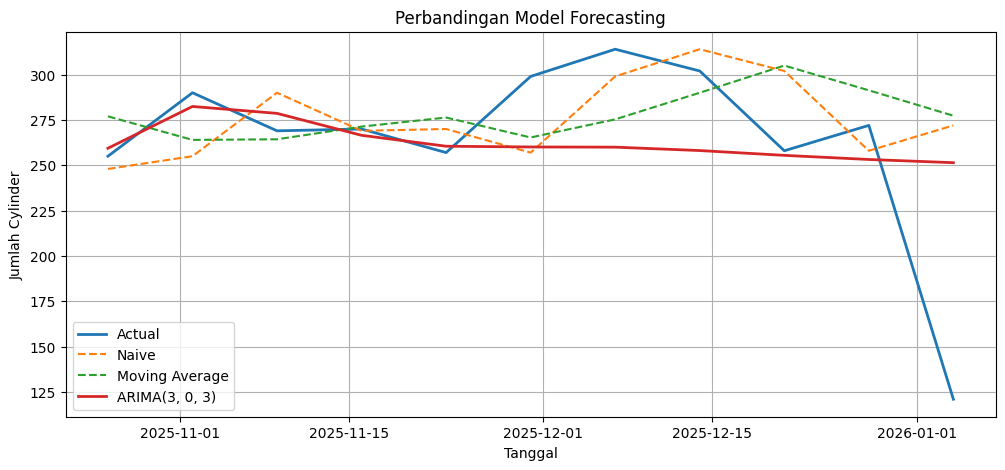

In [15]:
# =========================================
# VISUALISASI PERBANDINGAN MODEL
# =========================================

plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, naive_pred, label="Naive", linestyle="--")
plt.plot(test.index, ma_pred, label="Moving Average", linestyle="--")
plt.plot(test.index, arima_pred, label=f"ARIMA{best_order}", linewidth=2)

plt.title("Perbandingan Model Forecasting")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Cylinder")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
# =========================================
# FORECAST 4 MINGGU KE DEPAN
# =========================================

final_model = ARIMA(df_weekly, order=best_order)
final_fit = final_model.fit()

future = final_fit.forecast(steps=4)

print("Forecast 4 Minggu ke Depan:")
print(future)

Forecast 4 Minggu ke Depan:
2026-01-11    142.724240
2026-01-18    185.002712
2026-01-25    164.135176
2026-02-01    165.141735
Freq: W-SUN, Name: predicted_mean, dtype: float64


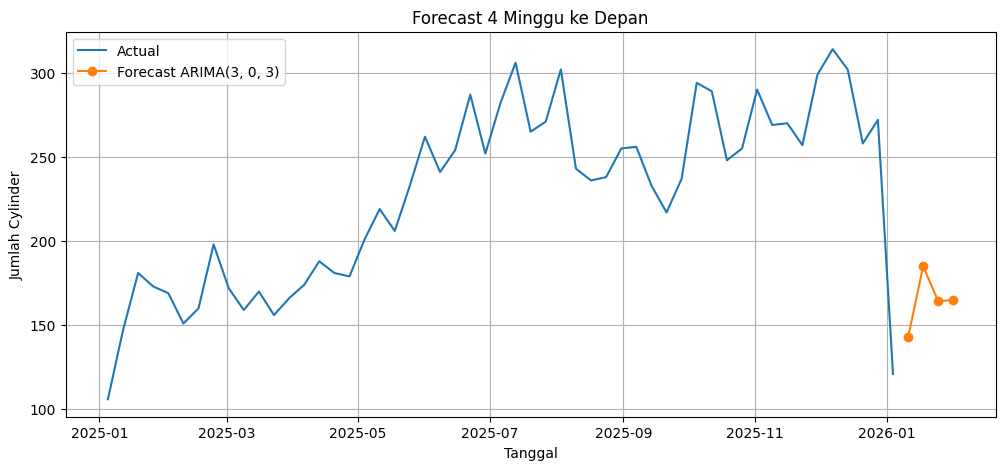

In [17]:
# =========================================
# VISUALISASI FORECAST 4 MINGGU KE DEPAN
# =========================================

plt.figure(figsize=(12, 5))

plt.plot(df_weekly.index, df_weekly, label="Actual")
plt.plot(future.index, future, label=f"Forecast ARIMA{best_order}", marker="o")

plt.title("Forecast 4 Minggu ke Depan")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Cylinder")
plt.legend()
plt.grid(True)

plt.show()

STREAMLIT


In [18]:
df_weekly.describe()

,Jumlah Cylinder
count,53.000000
mean,227.622642
std,53.305082
min,106.000000
25%,179.000000
50%,238.000000
75%,269.000000
max,314.000000
